# EDA - Phân tích khám phá dữ liệu Superstore

### 0. Đọc dữ liệu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"D:\DATN\DATN---Phantom-Data\Data dự án\cleaned\superstore_cleaned.csv")
df.head()

,category,city,country,customer_id,customer_name,discount,market,order_date,order_id,order_priority,...,state,sub_category,discount_pct,profit_margin,ship_delay_days,order_year,order_quarter,order_month,cohort_month,cohort_index
0,Office Supplies,Wagga Wagga,Australia,JH-159851,Joseph Holt,0.1,APAC,2011-01-01,IN-2011-47883,Medium,...,New South Wales,Paper,10.0,0.278909,7,2011,2011Q1,2011-01,2011-01,0
1,Office Supplies,Stockholm,Sweden,EM-141402,Eugene Moren,0.5,EU,2011-01-01,IT-2011-3647632,High,...,Stockholm,Paper,50.0,-0.579111,4,2011,2011Q1,2011-01,2011-01,0
2,Office Supplies,Constantine,Algeria,TB-112801,Toby Braunhardt,0.0,Africa,2011-01-01,AG-2011-2040,Medium,...,Constantine,Storage,0.0,0.260147,5,2011,2011Q1,2011-01,2011-01,0
3,Office Supplies,Wagga Wagga,Australia,JH-159851,Joseph Holt,0.1,APAC,2011-01-01,IN-2011-47883,Medium,...,New South Wales,Supplies,10.0,0.300333,7,2011,2011Q1,2011-01,2011-01,0
4,Office Supplies,Budapest,Hungary,AT-7352,Annie Thurman,0.0,EMEA,2011-01-01,HU-2011-1220,High,...,Budapest,Storage,0.0,0.449091,4,2011,2011Q1,2011-01,2011-01,0


### 1. Tổng quan dữ liệu

1.1. Số dòng và số cột

In [2]:
df.shape

(51252, 30)

1.2. Tên các cột

In [3]:
df.columns

Index(['category', 'city', 'country', 'customer_id', 'customer_name',
       'discount', 'market', 'order_date', 'order_id', 'order_priority',
       'product_id', 'product_name', 'profit', 'quantity', 'region', 'sales',
       'segment', 'ship_date', 'ship_mode', 'shipping_cost', 'state',
       'sub_category', 'discount_pct', 'profit_margin', 'ship_delay_days',
       'order_year', 'order_quarter', 'order_month', 'cohort_month',
       'cohort_index'],
      dtype='str')

1.3. Kiểu dữ liệu

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51252 entries, 0 to 51251
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   category         51252 non-null  str    
 1   city             51252 non-null  str    
 2   country          51252 non-null  str    
 3   customer_id      51252 non-null  str    
 4   customer_name    51252 non-null  str    
 5   discount         51252 non-null  float64
 6   market           51252 non-null  str    
 7   order_date       51252 non-null  str    
 8   order_id         51252 non-null  str    
 9   order_priority   51252 non-null  str    
 10  product_id       51252 non-null  str    
 11  product_name     51252 non-null  str    
 12  profit           51252 non-null  float64
 13  quantity         51252 non-null  int64  
 14  region           51252 non-null  str    
 15  sales            51252 non-null  int64  
 16  segment          51252 non-null  str    
 17  ship_date        51252 

### 2. Chất lượng dữ liệu

2.1. Dữ liệu thiếu

In [5]:
df.isnull().sum()

category           0
city               0
country            0
customer_id        0
customer_name      0
discount           0
market             0
order_date         0
order_id           0
order_priority     0
product_id         0
product_name       0
profit             0
quantity           0
region             0
sales              0
segment            0
ship_date          0
ship_mode          0
shipping_cost      0
state              0
sub_category       0
discount_pct       0
profit_margin      0
ship_delay_days    0
order_year         0
order_quarter      0
order_month        0
cohort_month       0
cohort_index       0
dtype: int64

2.2 Dữ liệu trùng lặp

In [6]:
df.duplicated().sum()

np.int64(0)

2.3. Chuyển đổi kiểu dữ liệu ngày tháng

In [7]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

### 3. Thống kê mô tả

3.1. Thống kê các chỉ số trung bình, độ lệch chuẩn, giá trị nhỏ nhất, lớn nhất và các phân vị

In [8]:
num_cols = [
    "sales",
    "profit",
    "quantity",
    "discount",
    "shipping_cost",
    "profit_margin",
    "ship_delay_days"
]
df[num_cols].describe()

,sales,profit,quantity,discount,shipping_cost,profit_margin,ship_delay_days
count,51252.000000,51252.000000,51252.000000,51252.000000,51252.000000,51252.000000,51252.000000
mean,246.382678,28.564047,3.476352,0.142970,26.370251,0.047062,3.969387
std,487.271939,174.306006,2.278404,0.212326,57.294439,0.466956,1.729401
min,0.000000,-6599.980000,1.000000,0.000000,0.000000,-4.727769,0.000000
25%,31.000000,0.000000,2.000000,0.000000,2.610000,0.000000,3.000000
50%,85.000000,9.240000,3.000000,0.000000,7.790000,0.169143,4.000000
75%,251.000000,36.780000,5.000000,0.200000,24.450000,0.333077,5.000000
max,22638.000000,8399.980000,14.000000,0.850000,933.570000,0.585000,7.000000


### 4. KPI tổng quan

In [9]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
profit_margin = total_profit / total_sales
loss_orders = df[df["profit"] < 0].shape[0]
loss_rate = loss_orders / df.shape[0]

print("Tổng doanh thu:", total_sales)
print("Tổng lợi nhuận:", total_profit)
print("Tỷ suất lợi nhuận:", profit_margin)
print("Số dòng bị lỗ:", loss_orders)
print("Tỷ lệ dòng bị lỗ:", loss_rate)

Tổng doanh thu: 12627605
Tổng lợi nhuận: 1463964.56
Tỷ suất lợi nhuận: 0.11593366754820095
Số dòng bị lỗ: 12537
Tỷ lệ dòng bị lỗ: 0.24461484429875907


### 5. Phân tích đơn biến

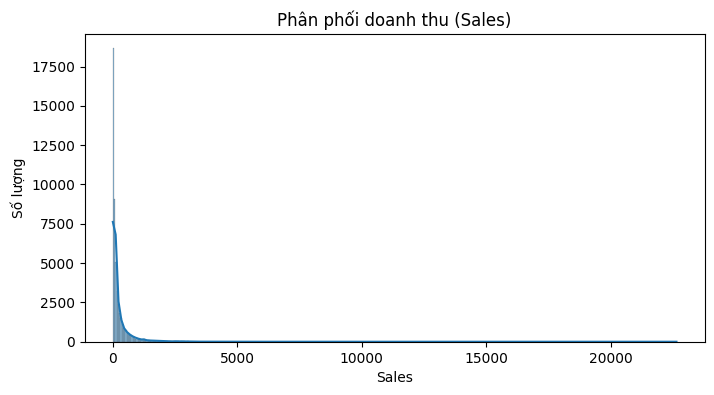

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df["sales"], kde=True)
plt.title("Phân phối doanh thu (Sales)")
plt.xlabel("Sales")
plt.ylabel("Số lượng")
plt.show()

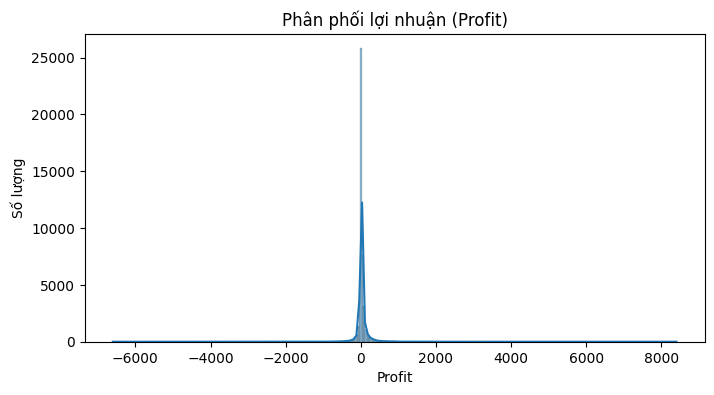

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(df["profit"], kde=True)
plt.title("Phân phối lợi nhuận (Profit)")
plt.xlabel("Profit")
plt.ylabel("Số lượng")
plt.show()

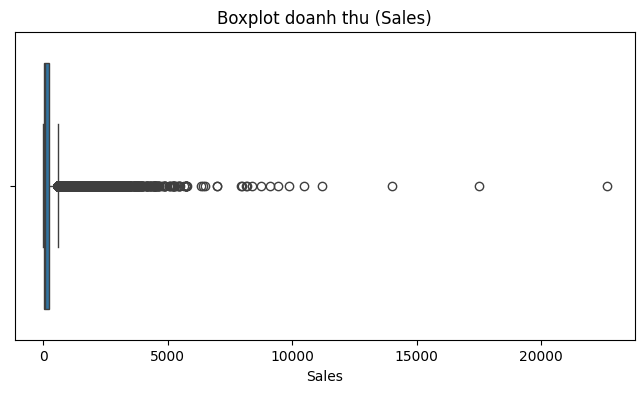

In [12]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["sales"])
plt.title("Boxplot doanh thu (Sales)")
plt.xlabel("Sales")
plt.show()

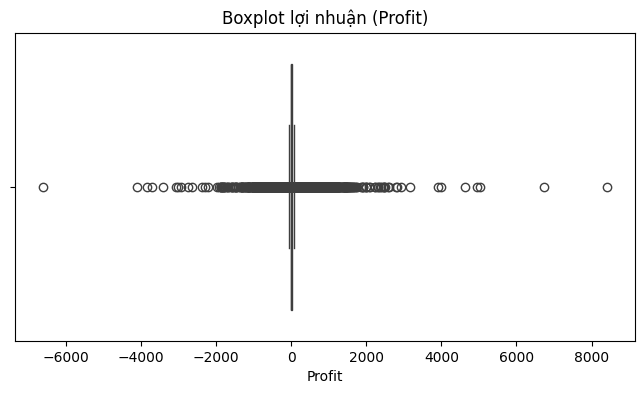

In [13]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["profit"])
plt.title("Boxplot lợi nhuận (Profit)")
plt.xlabel("Profit")
plt.show()

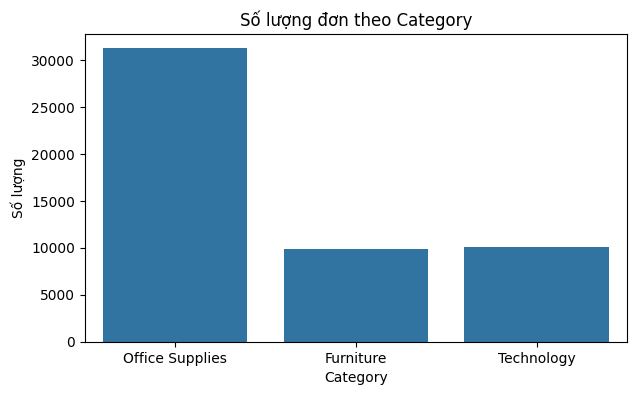

In [14]:
plt.figure(figsize=(7,4))
sns.countplot(x="category", data=df)
plt.title("Số lượng đơn theo Category")
plt.xlabel("Category")
plt.ylabel("Số lượng")
plt.show()

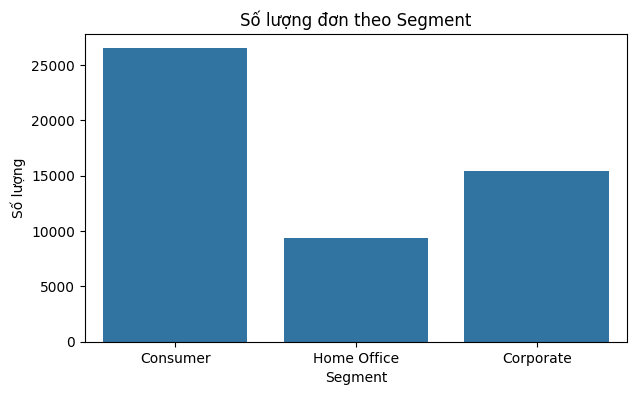

In [15]:
plt.figure(figsize=(7,4))
sns.countplot(x="segment", data=df)
plt.title("Số lượng đơn theo Segment")
plt.xlabel("Segment")
plt.ylabel("Số lượng")
plt.show()

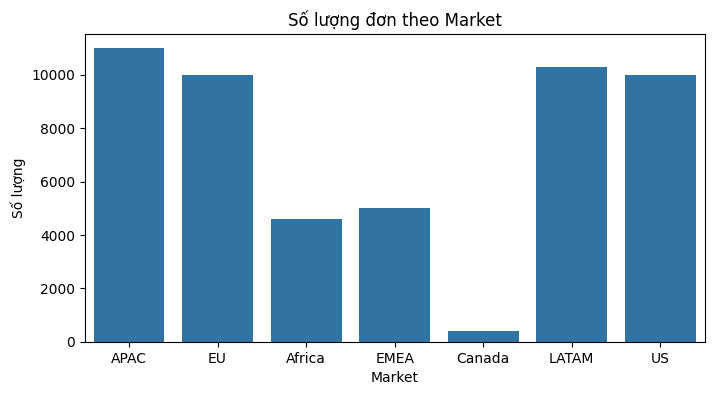

In [16]:
plt.figure(figsize=(8,4))
sns.countplot(x="market", data=df)
plt.title("Số lượng đơn theo Market")
plt.xlabel("Market")
plt.ylabel("Số lượng")
plt.show()

### 6. Phân tích đa biến

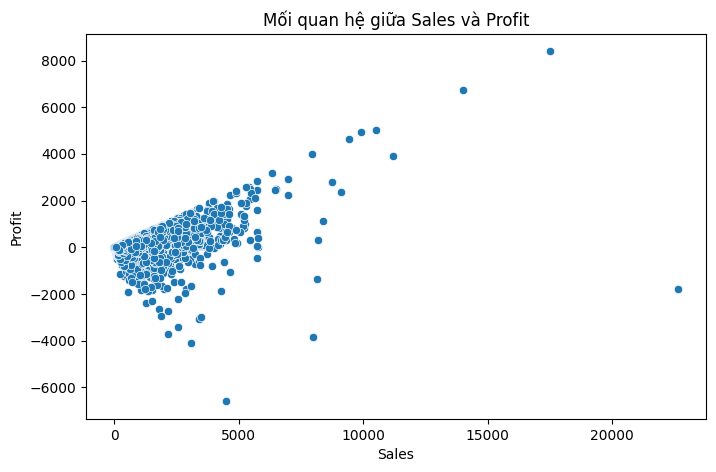

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="sales", y="profit", data=df)
plt.title("Mối quan hệ giữa Sales và Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

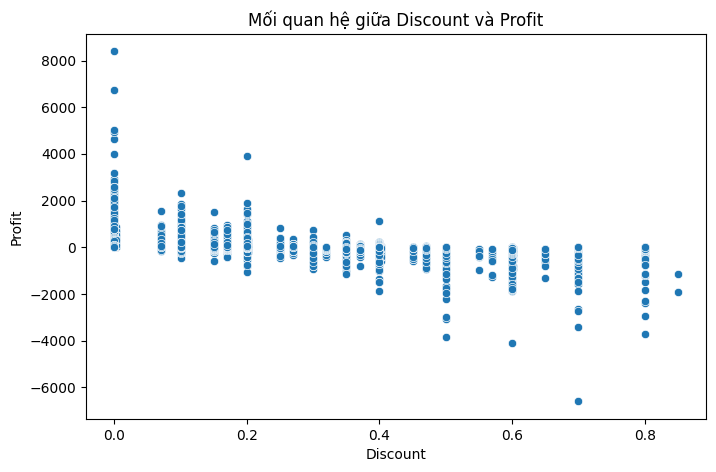

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="discount", y="profit", data=df)
plt.title("Mối quan hệ giữa Discount và Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [19]:
category_summary = df.groupby("category")[["sales", "profit"]].sum().reset_index()
category_summary

,category,sales,profit
0,Furniture,4108173,284889.59
1,Office Supplies,3778994,516726.13
2,Technology,4740438,662348.84


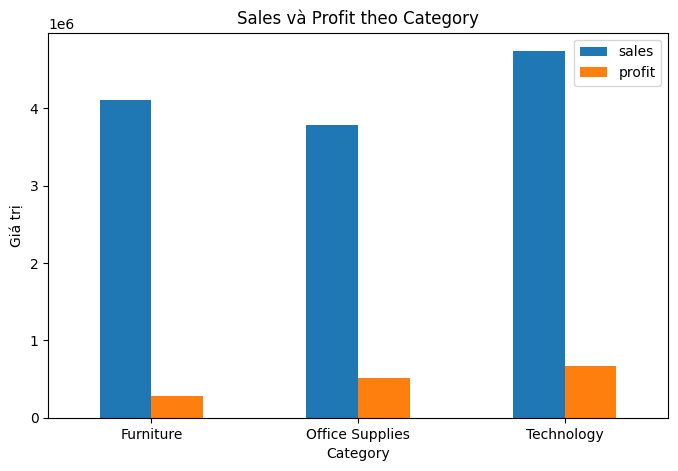

In [20]:
category_summary.plot(
    x="category",
    y=["sales", "profit"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales và Profit theo Category")
plt.xlabel("Category")
plt.ylabel("Giá trị")
plt.xticks(rotation=0)
plt.show()

In [21]:
year_summary = df.groupby("order_year")[["sales", "profit"]].sum().reset_index()
year_summary

,order_year,sales,profit
0,2011,2255587,247734.44
1,2012,2672571,306748.30
2,2013,3401762,405762.32
3,2014,4297685,503719.50


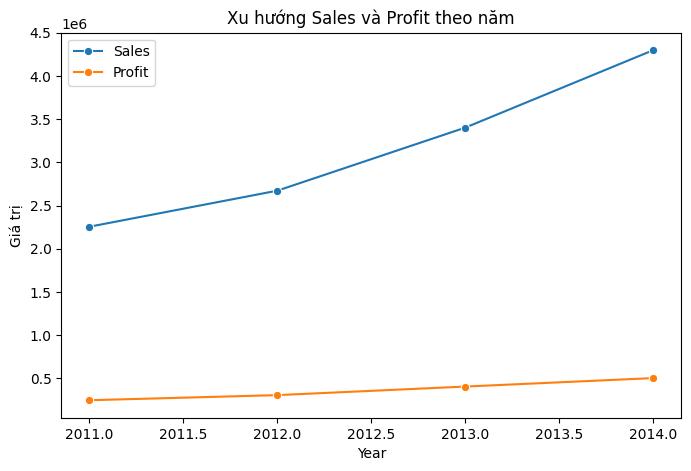

In [22]:
plt.figure(figsize=(8,5))
sns.lineplot(x="order_year", y="sales", data=year_summary, marker="o", label="Sales")
sns.lineplot(x="order_year", y="profit", data=year_summary, marker="o", label="Profit")
plt.title("Xu hướng Sales và Profit theo năm")
plt.xlabel("Year")
plt.ylabel("Giá trị")
plt.legend()
plt.show()

In [23]:
market_summary = df.groupby("market")[["sales", "profit"]].sum().reset_index()
market_summary

,market,sales,profit
0,APAC,3578606,433975.23
1,Africa,783128,88639.08
2,Canada,66932,17817.39
3,EMEA,806145,43884.76
4,EU,2937071,372580.78
5,LATAM,2160712,221281.49
6,US,2295011,285785.83


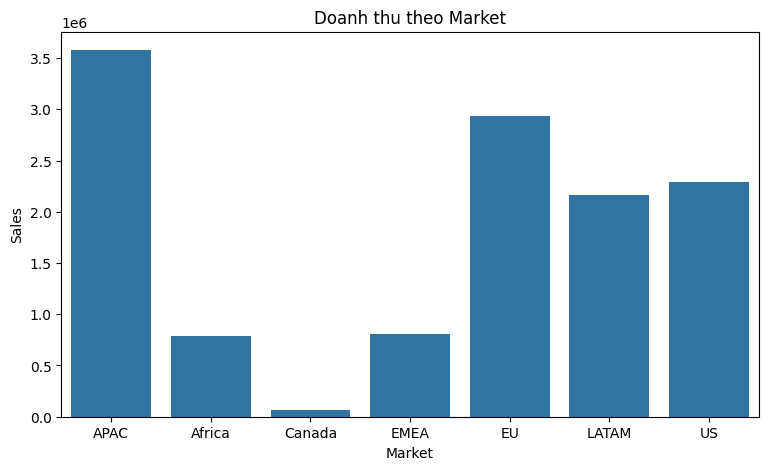

In [24]:
plt.figure(figsize=(9,5))
sns.barplot(x="market", y="sales", data=market_summary)
plt.title("Doanh thu theo Market")
plt.xlabel("Market")
plt.ylabel("Sales")
plt.show()

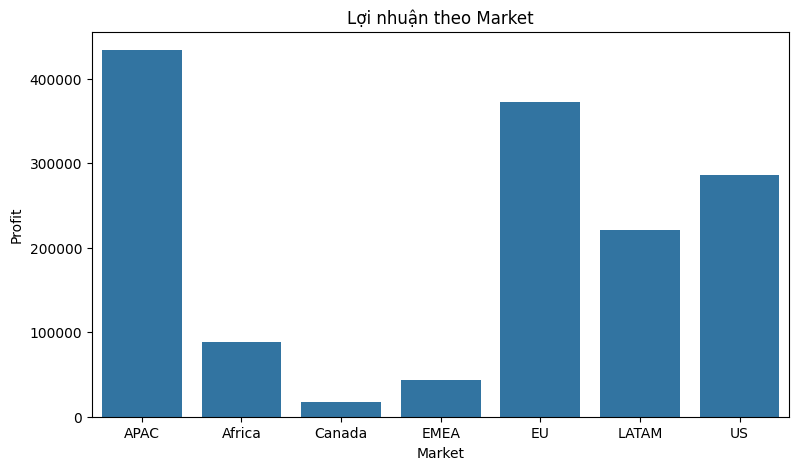

In [25]:
plt.figure(figsize=(9,5))
sns.barplot(x="market", y="profit", data=market_summary)
plt.title("Lợi nhuận theo Market")
plt.xlabel("Market")
plt.ylabel("Profit")
plt.show()

### 7. HEATMAP tương quan

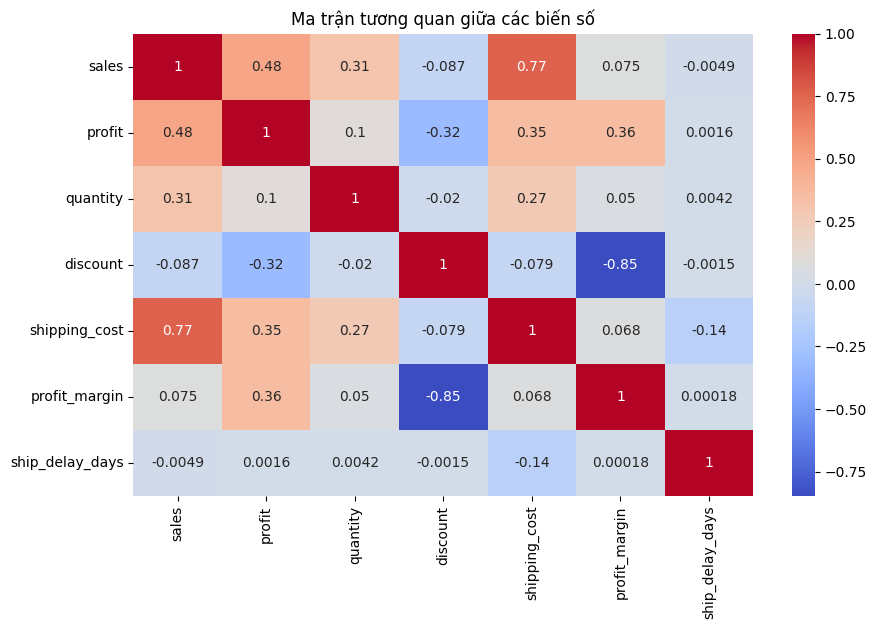

In [26]:
corr = df[num_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Ma trận tương quan giữa các biến số")
plt.show()

### 8. Phát hiện Insight

#### Insight 1: Một phần đơn hàng đang bị lỗ

Kết quả phân tích cho thấy có nhiều dòng dữ liệu có Profit âm. Điều này cho thấy không phải tất cả đơn hàng đều mang lại lợi nhuận cho doanh nghiệp.

Nguyên nhân có thể đến từ mức chiết khấu cao, chi phí vận chuyển lớn hoặc một số nhóm sản phẩm có biên lợi nhuận thấp.

In [27]:
loss_orders = df[df["profit"] < 0].shape[0]
total_orders = df.shape[0]
loss_rate = loss_orders / total_orders * 100

print("Tổng số dòng:", total_orders)
print("Số dòng bị lỗ:", loss_orders)
print("Tỷ lệ dòng bị lỗ:", round(loss_rate, 2), "%")

Tổng số dòng: 51252
Số dòng bị lỗ: 12537
Tỷ lệ dòng bị lỗ: 24.46 %


#### Insight 2: Chiết khấu cao có thể làm giảm lợi nhuận

Biểu đồ giữa Discount và Profit cho thấy khi mức chiết khấu tăng cao, Profit có xu hướng giảm và xuất hiện nhiều đơn hàng có lợi nhuận âm.

Điều này cho thấy doanh nghiệp cần kiểm soát chính sách giảm giá. Nếu giảm giá quá cao, doanh thu có thể tăng nhưng lợi nhuận lại bị ảnh hưởng tiêu cực.

In [28]:
discount_summary = df.groupby("discount")[["sales", "profit"]].sum().reset_index()
discount_summary.sort_values("discount")

,discount,sales,profit
0,0.000,6981835,1768135.59
1,0.002,261395,57976.65
2,0.070,121620,21148.52
3,0.100,1576546,258240.27
4,0.150,306037,27375.87
5,0.170,247244,28176.66
6,0.200,1203369,117629.10
7,0.202,16213,-595.26
8,0.250,88063,800.61
9,0.270,89007,-1764.53


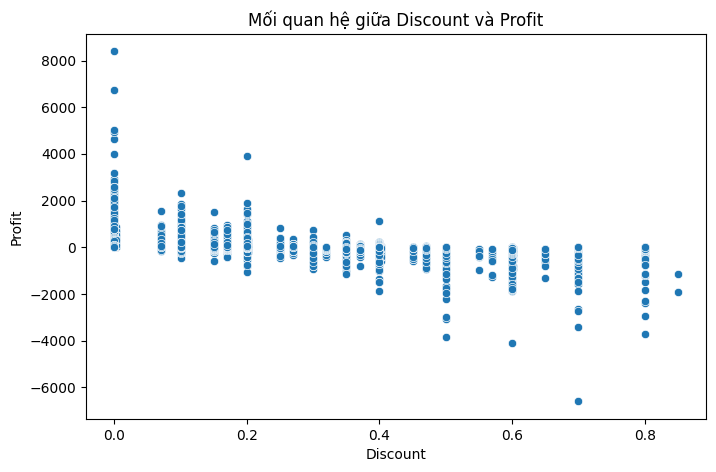

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="discount", y="profit", data=df)
plt.title("Mối quan hệ giữa Discount và Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

#### Insight 3: Doanh thu cao không luôn đồng nghĩa với lợi nhuận cao

Khi phân tích theo Category, có thể thấy Technology là nhóm có doanh thu và lợi nhuận cao. Tuy nhiên, Furniture tuy có doanh thu lớn nhưng tỷ suất lợi nhuận thấp hơn.

Điều này cho thấy doanh nghiệp không nên chỉ đánh giá hiệu quả kinh doanh bằng Sales, mà cần kết hợp thêm Profit và Profit Margin.

In [30]:
category_insight = df.groupby("category")[["sales", "profit"]].sum().reset_index()
category_insight["profit_margin"] = category_insight["profit"] / category_insight["sales"] * 100

category_insight.sort_values("sales", ascending=False)

,category,sales,profit,profit_margin
2,Technology,4740438,662348.84,13.972313
0,Furniture,4108173,284889.59,6.934703
1,Office Supplies,3778994,516726.13,13.673643


#### Insight 4: Một số nhóm sản phẩm con có nguy cơ gây lỗ

Kết quả phân tích theo Sub-category cho thấy có một số nhóm sản phẩm có lợi nhuận thấp hoặc âm, đặc biệt là nhóm Tables.

Đây là nhóm sản phẩm cần được xem xét lại về giá bán, chiết khấu, chi phí vận chuyển hoặc chiến lược kinh doanh.

In [31]:
sub_category_insight = df.groupby("sub_category")[["sales", "profit"]].sum().reset_index()
sub_category_insight["profit_margin"] = sub_category_insight["profit"] / sub_category_insight["sales"] * 100

sub_category_insight.sort_values("profit").head(10)

,sub_category,sales,profit,profit_margin
16,Tables,757034,-64083.49,-8.465074
8,Fasteners,83254,11525.33,13.843575
10,Labels,73422,15004.90,20.436518
15,Supplies,243052,22570.86,9.286433
7,Envelopes,170827,29579.33,17.315372
9,Furnishings,385036,46801.35,12.155058
2,Art,371353,57681.36,15.532757
11,Machines,778818,58758.92,7.544628
12,Paper,243938,59036.96,24.201625
3,Binders,461491,72361.35,15.679905


#### Insight 5: Doanh thu tập trung ở một số thị trường lớn

Phân tích theo Market cho thấy APAC là thị trường có doanh thu cao nhất, tiếp theo là EU, US và LATAM. Trong khi đó, Canada có doanh thu thấp nhất.

Tuy nhiên, doanh thu cao chưa chắc đồng nghĩa với hiệu quả cao. Doanh nghiệp cần so sánh thêm Profit và Profit Margin để xác định thị trường nào thật sự mang lại hiệu quả lợi nhuận tốt.

In [32]:
market_insight = df.groupby("market")[["sales", "profit"]].sum().reset_index()
market_insight["profit_margin"] = market_insight["profit"] / market_insight["sales"] * 100

market_insight.sort_values("sales", ascending=False)

,market,sales,profit,profit_margin
0,APAC,3578606,433975.23,12.126935
4,EU,2937071,372580.78,12.685454
6,US,2295011,285785.83,12.452482
5,LATAM,2160712,221281.49,10.241138
3,EMEA,806145,43884.76,5.443780
1,Africa,783128,88639.08,11.318594
2,Canada,66932,17817.39,26.620137


#### Insight 6: Hoạt động kinh doanh có xu hướng tăng theo năm

Kết quả phân tích theo năm cho thấy Sales và Profit đều tăng từ năm 2011 đến 2014. Điều này cho thấy hoạt động kinh doanh của Superstore có xu hướng mở rộng theo thời gian.

Tuy nhiên, doanh nghiệp vẫn cần theo dõi Profit Margin để đảm bảo lợi nhuận tăng tương xứng với doanh thu.

In [33]:
year_insight = df.groupby("order_year")[["sales", "profit"]].sum().reset_index()
year_insight["profit_margin"] = year_insight["profit"] / year_insight["sales"] * 100

year_insight

,order_year,sales,profit,profit_margin
0,2011,2255587,247734.44,10.983147
1,2012,2672571,306748.30,11.477648
2,2013,3401762,405762.32,11.928004
3,2014,4297685,503719.50,11.720717


### Tổng kết Insights

Từ quá trình EDA, có thể rút ra các phát hiện chính:

1. Có 12,537 dòng dữ liệu bị lỗ, chiếm khoảng 24.46% tổng dữ liệu.
2. Discount có xu hướng ảnh hưởng tiêu cực đến Profit, đặc biệt khi mức chiết khấu cao.
3. Doanh thu cao không phải lúc nào cũng đồng nghĩa với lợi nhuận cao.
4. Nhóm Furniture và đặc biệt là Sub-category Tables cần được xem xét kỹ hơn vì hiệu quả lợi nhuận thấp.
5. Doanh thu tập trung nhiều ở các thị trường lớn như APAC, EU, US và LATAM.
6. Sales và Profit có xu hướng tăng qua các năm, cho thấy hoạt động kinh doanh đang phát triển.

Các insights này giúp doanh nghiệp có cơ sở để kiểm soát chiết khấu, tối ưu nhóm sản phẩm và tập trung vào các thị trường có hiệu quả lợi nhuận tốt.